In [50]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, DataStructs
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
import matplotlib.pyplot as plt

In [51]:
df = pd.read_csv('nr_ic_merged.csv')

In [52]:
# Keep only valid SMILES
def smiles_to_mol(s):
    if pd.isna(s) or str(s).lower() == 'nan':
        return None
    try:
        return Chem.MolFromSmiles(str(s))
    except Exception:
        return None

df['mol'] = df['Smiles'].map(smiles_to_mol)
df = df[df['mol'].notna()].copy()

In [53]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe75967060>
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284d60>
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284eb0>
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284f20>
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284f90>
...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72174f90>
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72175000>
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72175070>
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe721750e0>


In [54]:
FPSIZE = 4096
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=FPSIZE)


def mol_to_fp(mol):
    fp = morgan_gen.GetFingerprint(mol)
    arr = np.zeros((FPSIZE,), dtype=int)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return arr


df['fp'] = df['mol'].map(mol_to_fp)

In [55]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe75967060>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284d60>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284eb0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284f20>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284f90>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ..."
...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72174f90>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72175000>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72175070>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe721750e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [56]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
target_encoded = encoder.fit_transform(df[['Target']])

# Store each one-hot vector as a list
df['target_encoded'] = target_encoded.tolist()

In [57]:
df

,Unnamed: 0,Molecule ChEMBL ID,Molecule Name,Smiles,Standard Type,Standard Value,Standard Units,pChEMBL Value,Target,mol,fp,target_encoded
0,0,CHEMBL390728,NaN,CCC1CCNc2cc3[nH]c(=O)cc(C(F)(F)F)c3cc21,IC50,4580.0,nM,5.34,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe75967060>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
1,1,CHEMBL3936931,NaN,O=C(N[C@H]1CC[C@H](Oc2ccnc3c(Br)cccc23)CC1)c1c...,IC50,190.0,nM,6.72,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284d60>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
2,2,CHEMBL418684,NaN,CC1=CC(C)(C)Nc2ccc3c(c21)COc1c(F)cc(F)cc1-3,IC50,644.0,nM,6.19,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284eb0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
3,3,CHEMBL235126,NaN,O=c1cc(O)c2cc(N(CC(F)(F)F)CC(F)(F)F)ccc2[nH]1,IC50,7.0,nM,8.15,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284f20>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
4,4,CHEMBL266491,NaN,COCCOc1ccccc1-c1ccc(C#N)c(C(F)(F)F)c1,IC50,2230.0,nM,5.65,ar,<rdkit.Chem.rdchem.Mol object at 0x7efe72284f90>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[1.0, 0.0, 0.0, 0.0, 0.0, 0.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...
14168,14168,CHEMBL118963,NaN,O=C1Nc2ccc(-c3cccc(Cl)c3)cc2C12CCCC2,IC50,32.0,nM,7.50,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72174f90>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14169,14169,CHEMBL117461,NaN,N#Cc1cc(F)cc(-c2ccc3c(c2)C2(CCCC2)C(=O)N3)c1,IC50,13.2,nM,7.88,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72175000>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14170,14170,CHEMBL117322,NaN,CC1C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,30.6,nM,7.51,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe72175070>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"
14171,14171,CHEMBL119058,NaN,CC1(C)C(=O)Nc2ccc(-c3cccc([N+](=O)[O-])c3)cc21,IC50,102.0,nM,6.99,pr,<rdkit.Chem.rdchem.Mol object at 0x7efe721750e0>,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 1.0]"


In [58]:
import numpy as np

# Convert fp arrays to tuples so they are hashable
df['fp_tuple'] = df['fp'].apply(lambda x: tuple(x))

# Group by fingerprint and OR-combine their one-hot target vectors
grouped = df.groupby('fp_tuple')['target_encoded'].apply(
    lambda rows: np.any(np.vstack(rows.values), axis=0).astype(int)
)

df_agg = grouped.reset_index()

# Convert fp back to numpy array
df_agg['fp'] = df_agg['fp_tuple'].apply(lambda x: np.array(x))

# Rename the aggregated target vector
df_agg = df_agg.rename(columns={'target_encoded': 'target'})

# Remove helper column
df_agg = df_agg.drop(columns=['fp_tuple'])

In [59]:
df_agg

,target,fp
0,"[0, 1, 1, 1, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,"[0, 1, 1, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,"[1, 0, 0, 0, 0, 0]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
...,...,...
7202,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7203,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7204,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
7205,"[0, 0, 0, 0, 0, 1]","[1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [60]:
x = np.vstack(df_agg['fp'].values)
y = np.vstack(df_agg['target'].values)

In [61]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=30, shuffle=True, random_state=42)

In [62]:
from sklearn.metrics import roc_auc_score

auc_per_fold = []

for train_index, test_index in kf.split(x):
    X_train, X_test = x[train_index], x[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = OneVsRestClassifier(
        RandomForestClassifier(
            n_estimators=50,
            max_depth=None,
            random_state=42,
            n_jobs=-1
        )
    )

    # Train
    model.fit(X_train, y_train)

    # Predict probabilities
    y_pred_prob_list = model.predict_proba(X_test)
    y_pred_prob_matrix = np.column_stack(y_pred_prob_list).T

    # Compute ROC-AUC per target
    roc_auc_per_target = [
        roc_auc_score(y_test[:, i], y_pred_prob_matrix[:, i])
        for i in range(y.shape[1])
    ]

    auc_per_fold.append(roc_auc_per_target)

# Convert to array for easier statistics
auc_per_fold = np.array(auc_per_fold)

# Mean and std per target
mean_auc = np.mean(auc_per_fold, axis=0)
std_auc = np.std(auc_per_fold, axis=0)

print("Mean ROC-AUC per target:", mean_auc)
print("Std ROC-AUC per target:", std_auc)
print("Overall mean ROC-AUC:", np.mean(mean_auc))

Mean ROC-AUC per target: [0.98070166 0.98667555 0.97998982 0.99034552 0.98147172 0.96786644]
Std ROC-AUC per target: [0.01513861 0.00481299 0.0109933  0.00806497 0.0186545  0.01970038]
Overall mean ROC-AUC: 0.9811751188275086


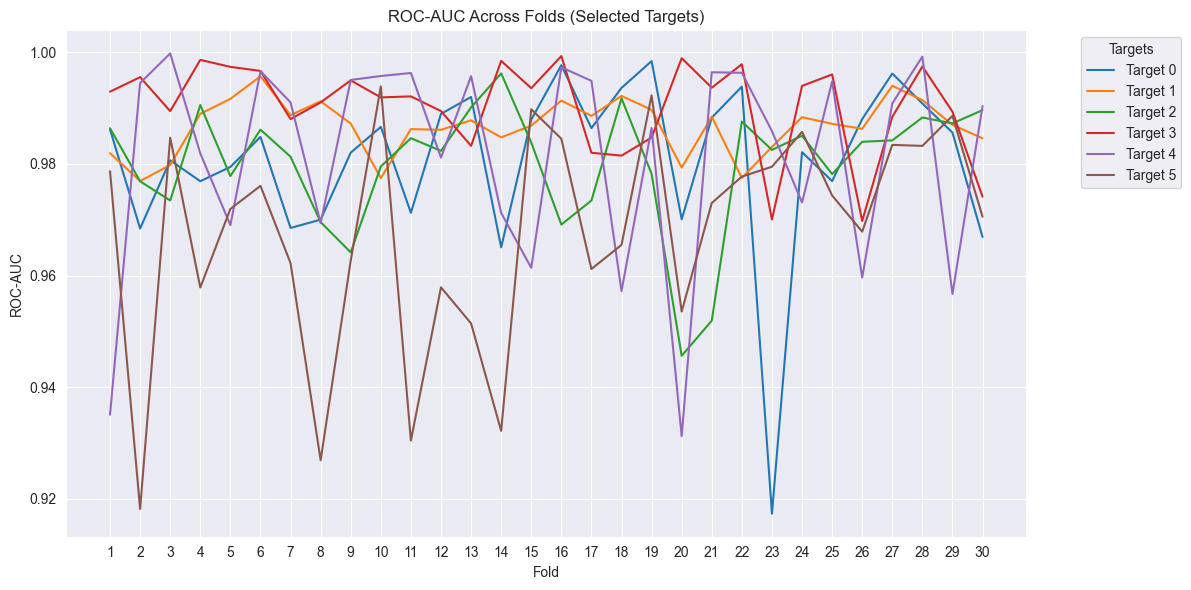

In [63]:
import matplotlib.pyplot as plt
import numpy as np

num_folds = auc_per_fold.shape[0]

num_targets = [0, 1, 2, 3, 4, 5]

plt.figure(figsize=(12, 6))

x_folds = np.arange(1, num_folds + 1)

for target_idx in num_targets:
    plt.plot(
        x_folds,
        auc_per_fold[:, target_idx],
        label=f"Target {target_idx}"
    )

plt.xlabel("Fold")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Across Folds (Selected Targets)")
plt.xticks(x_folds)  # force integer x-axis labels
plt.legend(title="Targets", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
